# Module 1 Notebook C: Linear Models With Libraries

This notebook covers the same concepts as scratch notebooks using `scikit-learn`:
- linear regression
- MSE vs MAE
- SGD optimization view
- overfitting/underfitting with polynomial features

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(123)
plt.rcParams['figure.figsize'] = (8, 4)

## 1) Baseline Linear Regression

In [2]:
X = np.linspace(0, 10, 220).reshape(-1, 1)
noise = np.random.normal(0, 2.0, size=(220,))
y = 4.2 * X[:, 0] - 1.5 + noise

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

lin = LinearRegression()
lin.fit(X_train, y_train)

pred_train = lin.predict(X_train)
pred_val = lin.predict(X_val)

print(f"coef={lin.coef_[0]:.3f}, intercept={lin.intercept_:.3f}")
print(f"Train MSE={mean_squared_error(y_train, pred_train):.3f}")
print(f"Val   MSE={mean_squared_error(y_val, pred_val):.3f}")
print(f"Val   MAE={mean_absolute_error(y_val, pred_val):.3f}")

coef=4.175, intercept=-1.339
Train MSE=4.332
Val   MSE=4.159
Val   MAE=1.651


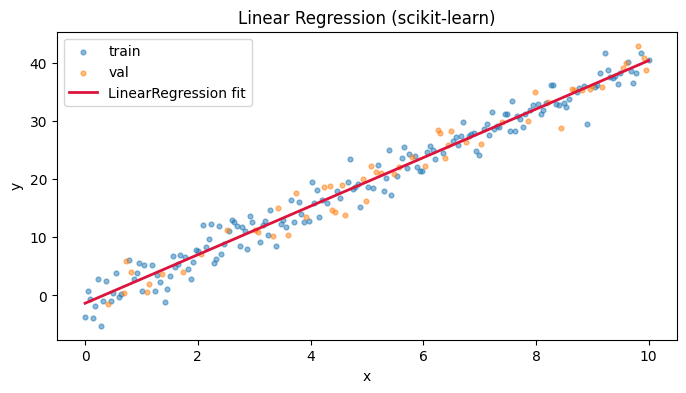

In [3]:
x_plot = np.linspace(0, 10, 200).reshape(-1, 1)
plt.scatter(X_train, y_train, s=12, alpha=0.5, label='train')
plt.scatter(X_val, y_val, s=12, alpha=0.5, label='val')
plt.plot(x_plot, lin.predict(x_plot), color='crimson', linewidth=2, label='LinearRegression fit')
plt.title('Linear Regression (scikit-learn)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

## 2) MSE vs MAE Under Outliers

In [4]:
# Create outlier-heavy validation labels
y_val_outlier = y_val.copy()
outlier_idx = np.random.choice(len(y_val_outlier), size=4, replace=False)
y_val_outlier[outlier_idx] += 35

pred_val = lin.predict(X_val)
print("Original validation:")
print(f"  MSE={mean_squared_error(y_val, pred_val):.3f}, MAE={mean_absolute_error(y_val, pred_val):.3f}")
print("With outliers:")
print(f"  MSE={mean_squared_error(y_val_outlier, pred_val):.3f}, MAE={mean_absolute_error(y_val_outlier, pred_val):.3f}")

Original validation:
  MSE=4.159, MAE=1.651
With outliers:
  MSE=91.185, MAE=4.099


## 3) Gradient Descent View With SGDRegressor

In [5]:
sgd = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SGDRegressor(
        loss='squared_error',
        penalty=None,
        learning_rate='constant',
        eta0=0.01,
        max_iter=3000,
        tol=1e-5,
        random_state=42
    ))
])

sgd.fit(X_train, y_train)
pred_val_sgd = sgd.predict(X_val)

print(f"SGD validation MSE={mean_squared_error(y_val, pred_val_sgd):.3f}")
print(f"SGD validation MAE={mean_absolute_error(y_val, pred_val_sgd):.3f}")

SGD validation MSE=4.144
SGD validation MAE=1.639


## 4) Underfit vs Overfit With Polynomial Features

In [6]:
# Nonlinear data
X2 = np.linspace(-3, 3, 180).reshape(-1, 1)
y2 = 0.5 * X2[:, 0]**3 - 1.2 * X2[:, 0]**2 + X2[:, 0] + 2 + np.random.normal(0, 1.4, size=180)

X2_train, X2_val, y2_train, y2_val = train_test_split(X2, y2, test_size=0.25, random_state=8)

def poly_model(degree, use_ridge=False):
    estimator = Ridge(alpha=1.0) if use_ridge else LinearRegression()
    return Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', estimator),
    ])

degrees = [1, 3, 6, 12]
for d in degrees:
    m = poly_model(d, use_ridge=False)
    m.fit(X2_train, y2_train)
    tr = mean_squared_error(y2_train, m.predict(X2_train))
    va = mean_squared_error(y2_val, m.predict(X2_val))
    print(f"degree={d:<2} train MSE={tr:7.3f} val MSE={va:7.3f}")

degree=1  train MSE= 17.776 val MSE= 20.235
degree=3  train MSE=  1.988 val MSE=  2.165
degree=6  train MSE=  1.961 val MSE=  2.212
degree=12 train MSE=  1.834 val MSE=  2.096


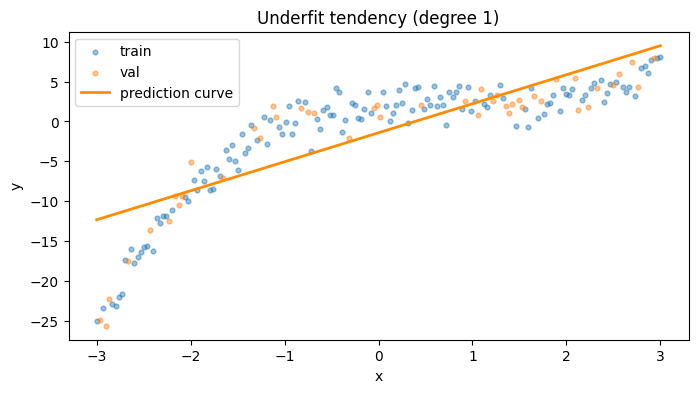

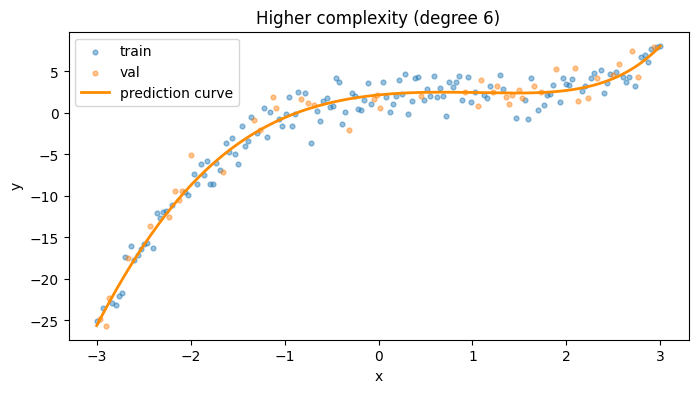

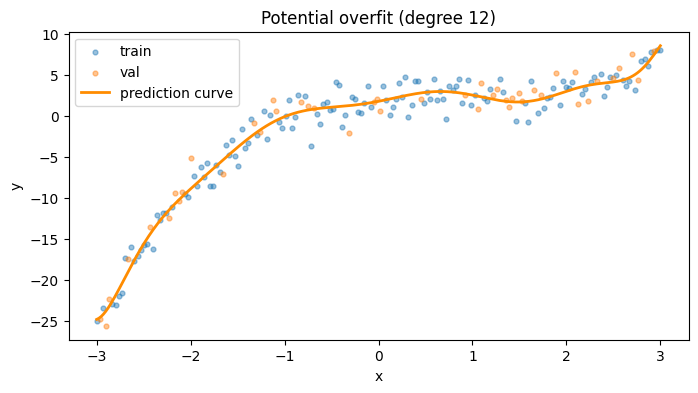

In [7]:
x_plot = np.linspace(-3, 3, 250).reshape(-1, 1)

for d, title in [(1, 'Underfit tendency (degree 1)'), (6, 'Higher complexity (degree 6)'), (12, 'Potential overfit (degree 12)')]:
    m = poly_model(d, use_ridge=False)
    m.fit(X2_train, y2_train)

    plt.figure(figsize=(8, 4))
    plt.scatter(X2_train, y2_train, s=12, alpha=0.45, label='train')
    plt.scatter(X2_val, y2_val, s=12, alpha=0.45, label='val')
    plt.plot(x_plot, m.predict(x_plot), color='darkorange', linewidth=2, label='prediction curve')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()

## 5) Regularization Preview (Ridge)

In [8]:
d = 12
plain = poly_model(d, use_ridge=False)
ridge = poly_model(d, use_ridge=True)

plain.fit(X2_train, y2_train)
ridge.fit(X2_train, y2_train)

print('Degree 12 (no regularization):')
print(f"  val MSE={mean_squared_error(y2_val, plain.predict(X2_val)):.3f}")
print('Degree 12 with Ridge(alpha=1.0):')
print(f"  val MSE={mean_squared_error(y2_val, ridge.predict(X2_val)):.3f}")

Degree 12 (no regularization):
  val MSE=2.096
Degree 12 with Ridge(alpha=1.0):
  val MSE=2.201


## Practice

1. Tune `eta0` in `SGDRegressor` and observe convergence quality.
2. Compare `LinearRegression` and `Ridge` across polynomial degrees.
3. Swap MSE metric with MAE and compare model ranking.